In [8077]:

try:
    import serial
    import numpy as np
    from matplotlib import pyplot as plt
except:
    %pip install pyserial
    %pip install numpy
    %pip install matplotlib
    import serial
    import numpy as np
    from matplotlib import pyplot as plt

In [8078]:
path_port_serial = "/dev/ttyUSB1"

In [8079]:
#l = serial.Serial()
#l.port=path_port_serial
#l.baudrate = 115200
#l.bytesize = 8
#l.open()
#l.write(bytearray([2]))
#l.close()



In [8080]:
import random as rd
import time

In [8081]:
def print_matrix(X):
  cmp = len(str(X[0][0]))
  for i in range(X.shape[0]):
    for j in range(X.shape[1]):
      if(X[i][j] ==0):
        print(f'0'*cmp,end=' ')
      else:
        print(f'{X[i][j]:d}',end=' ')
    print()

In [8082]:
def create_matrix(Din,BitsPorSimbolo):
  #Din = 8 #Diminsão das matrizes
  #DigitosPorSimbolo = 1 #digitos por elementos das matrizes
  Ain = np.zeros((Din,Din),dtype=int)
  Bin = np.zeros((Din,Din),dtype=int)
  for i in range(Din):
    for j in range(Din):
      Ain[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
      Bin[i][j] = rd.randint(1*(BitsPorSimbolo),1*9**(BitsPorSimbolo))
  return [Ain,Bin]

In [8083]:
#Preprocessamendo das matrizes
def shiftMatrixSystolic(X1:np.ndarray,X2:np.ndarray):
  Y1 = np.zeros((X1.shape[0],2*X1.shape[0]-1),dtype=int)
  Y2 = np.zeros((X2.shape[0],2*X2.shape[0]-1),dtype=int)
  for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
      if(j < X1.shape[1]):
        Y1[i][j+X1.shape[0]-i-1] = X1[i][j]
        Y2[i][j+X1.shape[0]-i-1] = X2[j][i]
        #Y2[i+j][j] = X2[i][j] #Transposta do segundo operando
        #Y2[i+j][i] = X2[i][j]
      else:
        Y1[i][j] = 0
        Y2[i][j] = 0
  return [Y1,Y2]


In [8084]:
#plt.subplot(1,2,1)
#plt.imshow(Ain)
#plt.subplot(1,2,2)
#plt.imshow(Bin)
#plt.show()


In [8085]:
#plt.subplot(1,2,1)
#plt.imshow(Ms[0])
#plt.subplot(1,2,2)#
#plt.imshow(Ms[1])
#plt.show()

In [8086]:
def send_matrix(X,input,flag):
  file = open(f"teste{input}.txt","+w")


  s = serial.Serial()
  s.port = path_port_serial
  s.baudrate = 115200
  s.bytesize = 8
  #fs = (s.baudrate)*(s.bytesize+2)*(1+1)#8 bits de dados e 1 de start 1 de stop
  fs = 100
  s.open()
  s.write(bytearray([255]))
  time.sleep(1/fs)
  s.write(bytearray([255]))
  time.sleep(1/fs)
  #file.write(f"assign {input}[{0}] = "+"8'b"+str(11111111)+";\n")
  for i in range(X.shape[1]):
    for j in range(X.shape[0]):
      s.write(bytearray([X[j][i]]))
      print(X[j][i])
      time.sleep(1/fs)
    #print('0b'+strbin,i)
    #print(int('0b'+strbin,2))
    #file.write(f"assign {input}[{i+1}] = "+"8'b"+strbin+";\n")
    #  time.sleep(1/Fs)  
  s.write(bytearray([255]))
  time.sleep(1/fs)
  s.write(bytearray([255]))
  time.sleep(1/fs)
  s.close()  
  #file.close()
 

In [8087]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
print_matrix(M[1])


5 3 5 1 
9 2 5 5 
5 2 4 2 
8 3 7 8 


In [8088]:

#M1 = np.array([[5,7,8],[9,8,7],[1,5,5]])
#M2 = np.array([[7,5,10],[8,8,9],[1,9,6]])

In [8089]:
#M = [M1,M2]

In [8090]:
M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))


In [8091]:
for i in range(1):
    print("Matriz -----------------------",i,"--------------------------")
    #M = create_matrix(Din = 4, BitsPorSimbolo=np.log2(2))
    M_p = shiftMatrixSystolic(M[0],M[1])
    print("A:")
    send_matrix(M_p[0],"INPUT_A1",1)
    print("B:")
    send_matrix(M_p[1],"INPUT_B1",1)
    


Matriz ----------------------- 0 --------------------------
A:
0
0
0
3
0
0
6
4
0
1
2
3
6
3
9
4
5
3
6
0
9
4
0
0
6
0
0
0
B:
0
0
0
7
0
0
4
7
0
5
8
8
7
4
4
4
8
2
2
0
7
5
0
0
1
0
0
0


M_p[0]@

In [8092]:
M[0]

array([[6, 5, 9, 6],
       [1, 3, 3, 4],
       [6, 2, 9, 6],
       [3, 4, 3, 4]])

In [8093]:
M[1]

array([[7, 5, 4, 7],
       [8, 4, 8, 7],
       [7, 2, 4, 8],
       [1, 5, 2, 4]])

In [8094]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8095]:
M[1]@M[0]

array([[ 92,  86, 135, 114],
       [121,  96, 177, 140],
       [ 92,  81, 129, 106],
       [ 35,  40,  54,  54]])

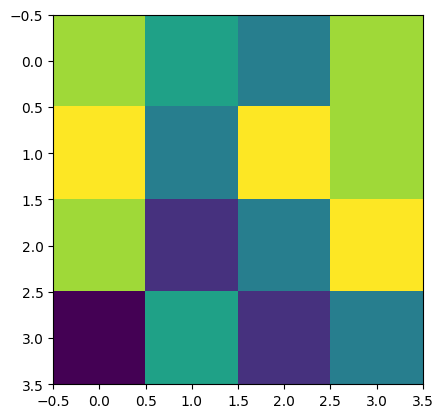

In [8096]:
plt.imshow(M[1])

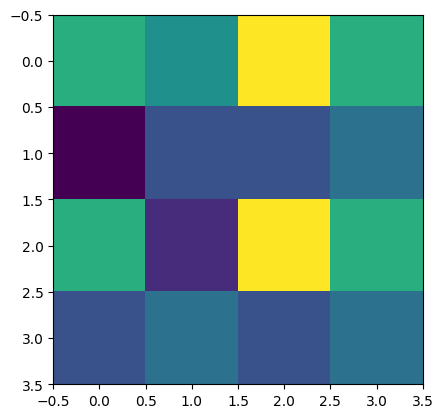

In [8097]:
plt.imshow(M[0])

In [8098]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

M_p = shiftMatrixSystolic(M[0],M[1])

In [8099]:
M[1]@M[0]

array([[ 92,  86, 135, 114],
       [121,  96, 177, 140],
       [ 92,  81, 129, 106],
       [ 35,  40,  54,  54]])

In [8100]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8101]:
M_p = shiftMatrixSystolic(M[0],M[0])
M_p[0],M_p[1]

(array([[0, 0, 0, 6, 5, 9, 6],
        [0, 0, 1, 3, 3, 4, 0],
        [0, 6, 2, 9, 6, 0, 0],
        [3, 4, 3, 4, 0, 0, 0]]),
 array([[0, 0, 0, 6, 1, 6, 3],
        [0, 0, 5, 3, 2, 4, 0],
        [0, 9, 3, 9, 3, 0, 0],
        [6, 4, 6, 4, 0, 0, 0]]))

In [8102]:
#M = create_matrix(Din = 16, PorSimbolo=1)

In [8103]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8104]:
M

[array([[6, 5, 9, 6],
        [1, 3, 3, 4],
        [6, 2, 9, 6],
        [3, 4, 3, 4]]),
 array([[7, 5, 4, 7],
        [8, 4, 8, 7],
        [7, 2, 4, 8],
        [1, 5, 2, 4]])]

In [8105]:
M_p[0]

array([[0, 0, 0, 6, 5, 9, 6],
       [0, 0, 1, 3, 3, 4, 0],
       [0, 6, 2, 9, 6, 0, 0],
       [3, 4, 3, 4, 0, 0, 0]])

In [8106]:
M_p[1]

array([[0, 0, 0, 6, 1, 6, 3],
       [0, 0, 5, 3, 2, 4, 0],
       [0, 9, 3, 9, 3, 0, 0],
       [6, 4, 6, 4, 0, 0, 0]])

In [8107]:
def send_matrix(X,input,flag):
  file = open(f"../teste{input}.mem","+w")
  #file.write(f"assign {input}[{0}] = "+"32'"+"h"+str("ffffffff")+";\n")
  k = 0
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
  for i in range(X.shape[1]):
    strbin = 0
    for j in range(X.shape[0]):
        file.write(f'{X[j][i]:02d}'+"\n")
        #file.write(f"assign {input}[{k:03}] = "+"8'"+"h"+f'{X[j][i]:02d}'+";\n")
        k =k+1
        #strbin+= int(X[j][i]*pow(10,X.shape[0]-1-j))
    #print(f'{strbin:016d}',i)
   # print(int('0b'+strbin,2))
   # file.write(f"assign {input}[{i+1}] = "+"32'"+"h"+f'{strbin:08d}'+";\n")
  #file.close()
  file.write(f'{0XFF:02X}'+"\n")
  file.write(f'{0XFF:02X}'+"\n")
for i in range(1):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A1",0)
    send_matrix(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [8108]:
len(str("0000000000000009"))*4


64

In [8109]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8110]:
M_p[1]

array([[0, 0, 0, 7, 8, 7, 1],
       [0, 0, 5, 4, 2, 5, 0],
       [0, 4, 8, 4, 2, 0, 0],
       [7, 7, 8, 4, 0, 0, 0]])

In [8111]:
M_p[0]

array([[0, 0, 0, 6, 5, 9, 6],
       [0, 0, 1, 3, 3, 4, 0],
       [0, 6, 2, 9, 6, 0, 0],
       [3, 4, 3, 4, 0, 0, 0]])

In [8112]:
print_matrix(M[0]@M[1])

151 98 112 173 
56 43 48 68 
127 86 88 152 
78 57 64 89 


In [8113]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8114]:
shiftMatrixSystolic(M[0],M[1])

[array([[0, 0, 0, 6, 5, 9, 6],
        [0, 0, 1, 3, 3, 4, 0],
        [0, 6, 2, 9, 6, 0, 0],
        [3, 4, 3, 4, 0, 0, 0]]),
 array([[0, 0, 0, 7, 8, 7, 1],
        [0, 0, 5, 4, 2, 5, 0],
        [0, 4, 8, 4, 2, 0, 0],
        [7, 7, 8, 4, 0, 0, 0]])]

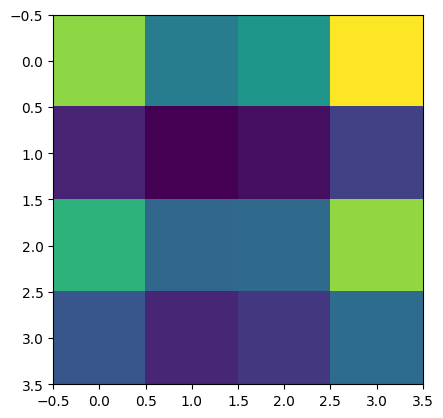

In [8115]:
plt.imshow(M[0]@M[1])

plt.show()

In [8116]:

for i in range(100):
    print("----------------------",i,"--------------------------")
    M_p = shiftMatrixSystolic(M[0],M[1])
    #Bin = M[1]
    send_matrix(M_p[0],"INPUT_A1",0)
    send_matrix(M_p[1],"INPUT_B1",0)
    
    break
    time.sleep(10)

#send_matrix(Bin)

---------------------- 0 --------------------------


In [8117]:
M[0]

array([[6, 5, 9, 6],
       [1, 3, 3, 4],
       [6, 2, 9, 6],
       [3, 4, 3, 4]])

In [8118]:
M[1]

array([[7, 5, 4, 7],
       [8, 4, 8, 7],
       [7, 2, 4, 8],
       [1, 5, 2, 4]])

In [8119]:
M[0]@M[1]

array([[151,  98, 112, 173],
       [ 56,  43,  48,  68],
       [127,  86,  88, 152],
       [ 78,  57,  64,  89]])

In [8120]:
s = serial.Serial()

s.port = path_port_serial
s.baudrate = 115200
s.bytesize = 8
s.close()
s.open()

In [8121]:
i =1
s.write(bytearray([int(i)]))


1

In [8122]:
serial.Serial()

Serial<id=0x7f2fbeb2b130, open=False>(port=None, baudrate=9600, bytesize=8, parity='N', stopbits=1, timeout=None, xonxoff=False, rtscts=False, dsrdtr=False)